# Lean Activity Correlation Notebook

Minimal notebook: choose activity, run analysis, inspect metrics, and plot results.

### Math & Reasoning
This cell defines the analytical toolbox. The notebook separates **data engineering** (utilities) from **statistical interpretation** (notebook outputs), so later cells can focus on inference rather than implementation details.

In [1]:
import os
import sys
import pandas as pd

sys.path.append('.')

from utilities.training_glucose_utils import (
    AnalysisConfig,
    list_activities,
    choose_activity,
    run_activity_analysis,
    plot_hr_bg_timeseries,
    plot_scatter_correlations,
    plot_lag_correlation,
    plot_delay_adjusted_overlay,
    build_shifted_bg_power_df,
    plot_gam_surface_and_fit,
    run_single_activity_gam,
    run_pooled_gam,
    compute_best_bg_by_hr_bin,
    plot_best_bg_by_hr_bin,
)

pd.set_option('display.max_columns', 200)




## Config

### Math & Reasoning
This cell sets the model assumptions and hyperparameters (bin size, lag tolerance, quantile threshold). These parameters determine smoothing strength and therefore the variance-bias tradeoff of downstream correlations.

In [2]:
os.environ["INTERVALS_ATHLETE_ID"] = "i298161"
os.environ["INTERVALS_API_KEY"]="59inwnqxsjucv0pp5gnbwunh"
# os.environ["NIGHTSCOUT_BASE_URL"]="https://p01--nightscout--jfv4bxh9hrff.code.run/"
cfg = AnalysisConfig(
    intervals_base_url=os.getenv('INTERVALS_BASE_URL', 'https://intervals.icu'),
    intervals_api_key=os.getenv('INTERVALS_API_KEY', ''),
    intervals_athlete_id=os.getenv('INTERVALS_ATHLETE_ID', '0'),
    intervals_streams_base_url=os.getenv('INTERVALS_STREAMS_BASE_URL', ''),
    nightscout_base_url=os.getenv('NIGHTSCOUT_BASE_URL', '').rstrip('/'),
    nightscout_token=os.getenv('NIGHTSCOUT_TOKEN', ''),
    nightscout_api_secret=os.getenv('NIGHTSCOUT_API_SECRET', ''),
    pre_activity_hours=int(os.getenv('PRE_ACTIVITY_HOURS', '2')),
    post_activity_hours=int(os.getenv('POST_ACTIVITY_HOURS', '6')),
    merge_tolerance=os.getenv('MERGE_TOLERANCE', '3min'),
)

BIN_SIZE = '5min'
HI_QUANTILE = float(os.getenv('HI_QUANTILE', '0.85'))

if not cfg.intervals_api_key:
    raise ValueError('Set INTERVALS_API_KEY')
if not cfg.nightscout_base_url:
    raise ValueError('Set NIGHTSCOUT_BASE_URL')

cfg

AnalysisConfig(intervals_base_url='https://intervals.icu', intervals_api_key='59inwnqxsjucv0pp5gnbwunh', intervals_athlete_id='i298161', intervals_streams_base_url='', nightscout_base_url='https://p01--nightscout--jfv4bxh9hrff.code.run', nightscout_token='', nightscout_api_secret='', pre_activity_hours=2, post_activity_hours=6, merge_tolerance='3min')

## Choose Activity

### Math & Reasoning
This cell defines the sampling frame (recent activities). The statistical validity of pooled results depends on this selection window because it controls the mixture of training intensities and physiological states.

In [3]:
activities_df = list_activities(cfg, days_back=120).reset_index(drop=True)
cols = [c for c in ['start_date_local', 'type', 'name', 'distance', 'moving_time', 'elapsed_time'] if c in activities_df.columns]
activities_df[cols].head(30)

,start_date_local,type,name,distance,moving_time,elapsed_time
0,2026-03-23 17:51:54,Ride,Berlin Road Cycling,41249.99,5683,5940
1,2026-03-23 09:20:03,Run,Berlin Running,4101.29,2007,2679
2,2026-03-20 08:31:01,Ride,Florence Road Cycling,112683.52,18144,22007
3,2026-03-19 19:58:11,Ride,Sesto Fiorentino Cycling,4973.78,1096,1107
4,2026-03-19 17:22:33,Ride,Florence Cycling,5413.76,1235,1261
5,2026-03-18 20:12:59,Ride,Florence Cycling,6120.80,2034,2497
6,2026-03-18 18:23:39,Ride,Florence Cycling,6565.15,1574,2044
7,2026-03-18 11:47:39,Ride,Florence Road Cycling,23197.77,5453,5822
8,2026-03-17 11:48:41,Ride,Sesto Fiorentino Road Cycling,33914.31,5199,5507
9,2026-03-15 09:55:23,Ride,Sesto Fiorentino Road Cycling,175151.62,25193,27260


### Math & Reasoning
This cell chooses the individual experiment unit (one activity). Single-activity analyses estimate local relationships that can differ from pooled/global relationships.

In [4]:
SELECTED_ACTIVITY_INDEX = 2
selected_activity = choose_activity(activities_df, SELECTED_ACTIVITY_INDEX)
selected_activity

{'id': 'i133474657',
 'start_date_local': Timestamp('2026-03-20 08:31:01'),
 'type': 'Ride',
 'name': 'Florence Road Cycling',
 'distance': 112683.52,
 'moving_time': 18144,
 'elapsed_time': 22007,
 'icu_ignore_time': False,
 'icu_pm_cp': 221.0,
 'icu_pm_w_prime': 18936.0,
 'icu_pm_p_max': 794.0,
 'icu_pm_ftp': 226.0,
 'icu_pm_ftp_secs': 1740.0,
 'icu_pm_ftp_watts': 232.0,
 'icu_ignore_power': False,
 'icu_rolling_cp': None,
 'icu_rolling_w_prime': 20398.465,
 'icu_rolling_p_max': 1107.5304,
 'icu_rolling_ftp': 248.0,
 'icu_rolling_ftp_delta': 0.0,
 'icu_training_load': 335,
 'icu_atl': 116.18607,
 'icu_ctl': 83.663185,
 'ss_p_max': 5.40407,
 'ss_w_prime': 15.812287,
 'ss_cp': 343.11902,
 'paired_event_id': None,
 'icu_ftp': 249.0,
 'icu_joules': 3096212.0,
 'icu_recording_time': 18274,
 'icu_weighted_avg_watts': 203.0,
 'carbs_used': 685.0,
 'description': None,
 'start_date': '2026-03-20T07:31:01Z',
 'icu_distance': 112683.52,
 'coasting_time': 2629.0,
 'total_elevation_gain': 1925.0

## Run Analysis

### Math & Reasoning
This cell executes the full transformation pipeline: align HR/power with BG, apply 5-minute binning, compute lag scans, and produce summary metrics. Binning reduces noise and stabilizes estimates for nonlinear models.

In [5]:
result = run_activity_analysis(
    cfg=cfg,
    activity=selected_activity,
    bin_size=BIN_SIZE,
    hi_quantile=HI_QUANTILE,
    requested_streams='time,heartrate,power',
)

print('Stream fetch used:', result['stream_meta'])
print('Available stream keys:', result['stream_keys'])
print('Binned samples:', len(result['aligned_df']))

Stream fetch used: {'target': 'https://intervals.icu/api/v1/activity/i133474657/streams.json', 'params': {'streams': 'time,heartrate,power'}, 'auth': 'basic'}
Available stream keys: ['altitude', 'cadence', 'distance', 'heartrate', 'latlng', 'left_pedal_smoothness', 'left_torque_effectiveness', 'temp', 'time', 'torque', 'velocity_smooth', 'watts']
Binned samples: 65


## Correlation Metrics (Main Output)

### Math & Reasoning
This cell reports core statistics: Pearson/Spearman, high-intensity conditional correlation, and best lag. These metrics provide linear and monotonic association views before nonlinear GAM modeling.

In [6]:
result['corr_summary']

samples_aligned                       65.000000
high_intensity_hr_threshold          164.392000
pearson_hr_bg                         -0.170408
spearman_hr_bg                         0.006862
pearson_hr_bg_high_intensity_only      0.239658
pearson_high_intensity_flag_vs_bg      0.101490
pearson_power_bg                      -0.356967
best_abs_lag_minutes                  -5.000000
best_abs_lag_corr                     -0.336069
dtype: float64

## Plots

### Math & Reasoning
This cell visualizes the binned time series and pairwise relationships to check shape, heteroscedasticity, and lag structure before fitting nonlinear models.

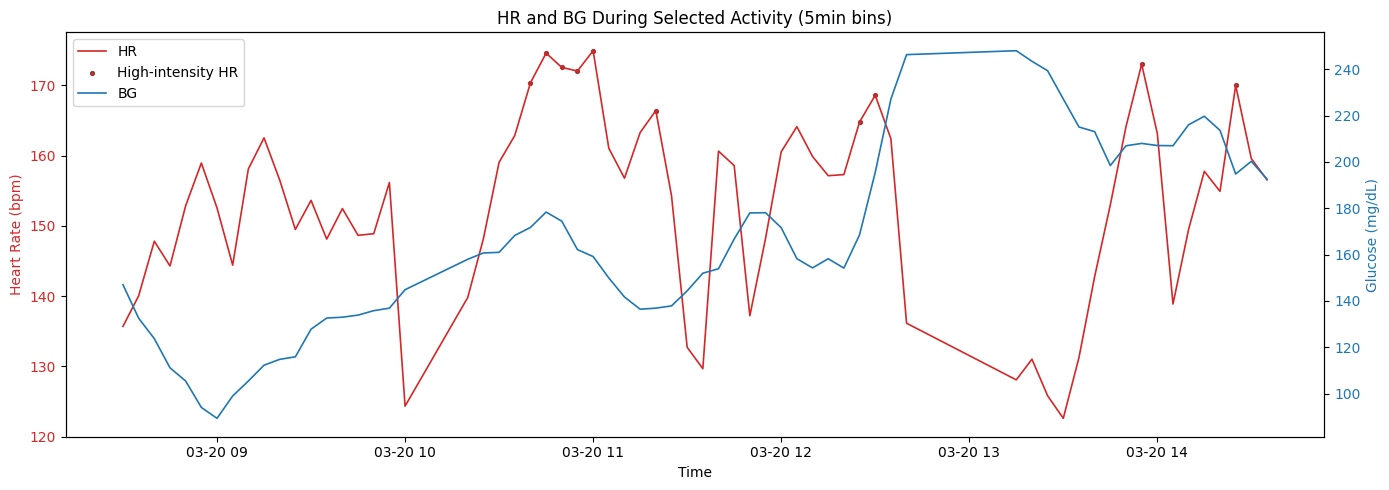

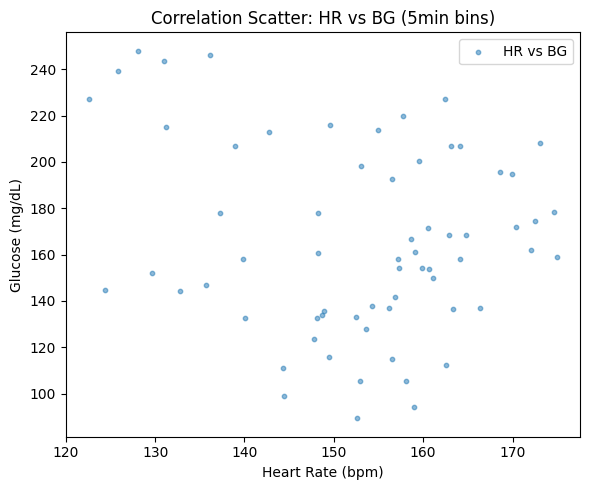

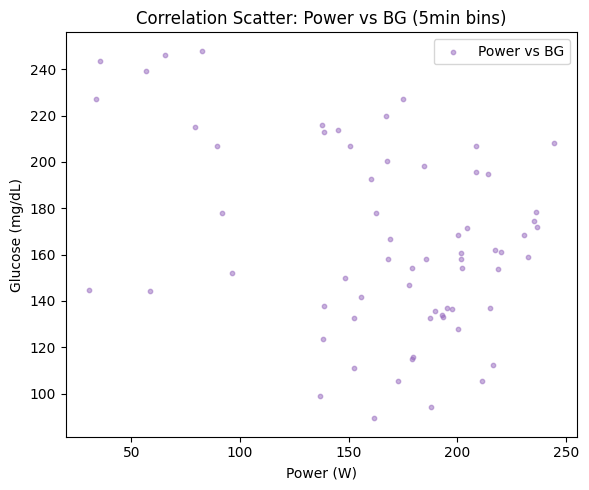

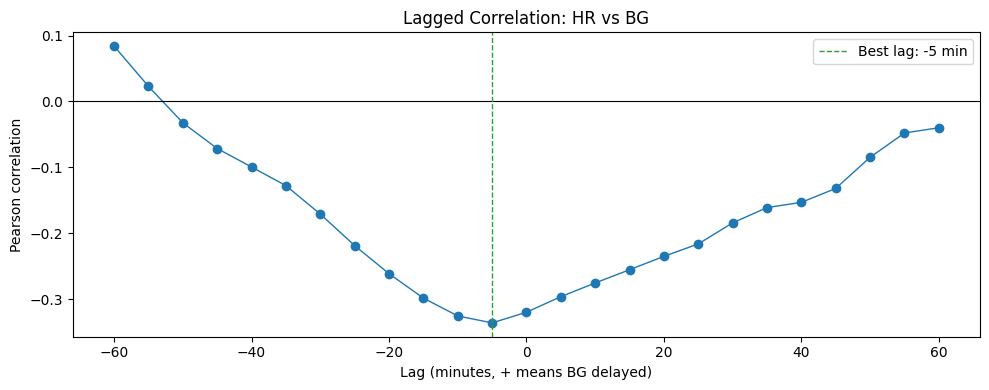

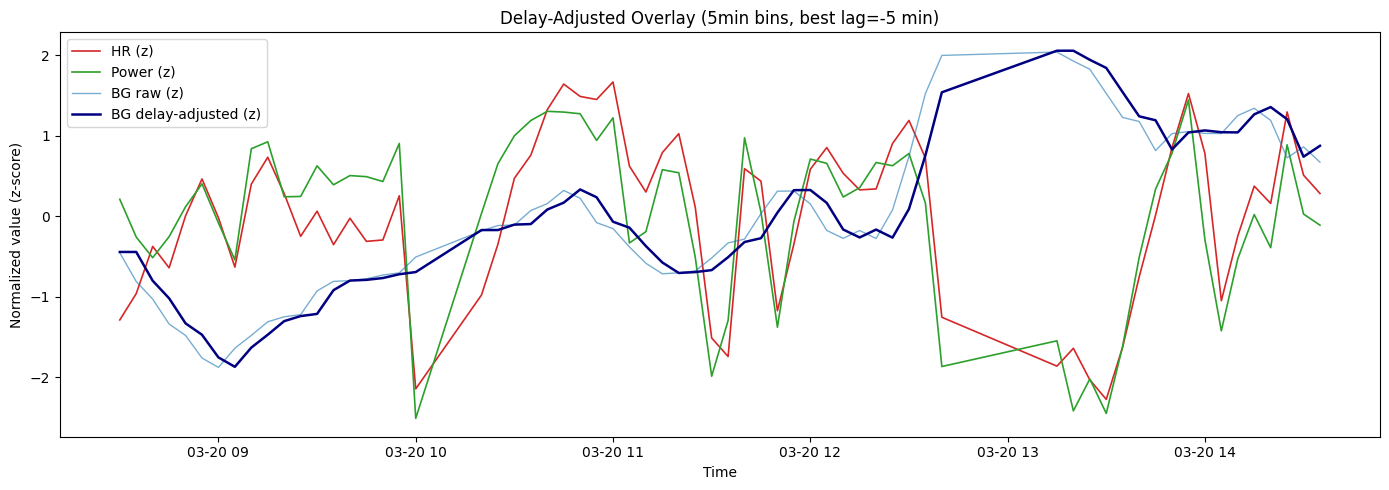

In [7]:
aligned_df = result['aligned_df']
lag_corr_df = result['lag_corr_df']

plot_hr_bg_timeseries(aligned_df, hi_quantile=HI_QUANTILE, bin_size=BIN_SIZE)
plot_scatter_correlations(aligned_df, bin_size=BIN_SIZE)
plot_lag_correlation(lag_corr_df)
overlay_df = plot_delay_adjusted_overlay(aligned_df, lag_corr_df, bin_size=BIN_SIZE)

## Shifted BG GAM (Power-HR-BG)

Model power as a smooth function of HR and lag-shifted BG using a Generalized Additive Model (GAM).

### Math & Reasoning
This cell fits a **single-activity GAM**: power ~ s(HR) + s(shifted BG) + interaction. It captures nonlinear and interaction effects specific to one session.

GAM samples: 65
Best lag used for BG shift: -5 min
In-sample R^2: 0.420


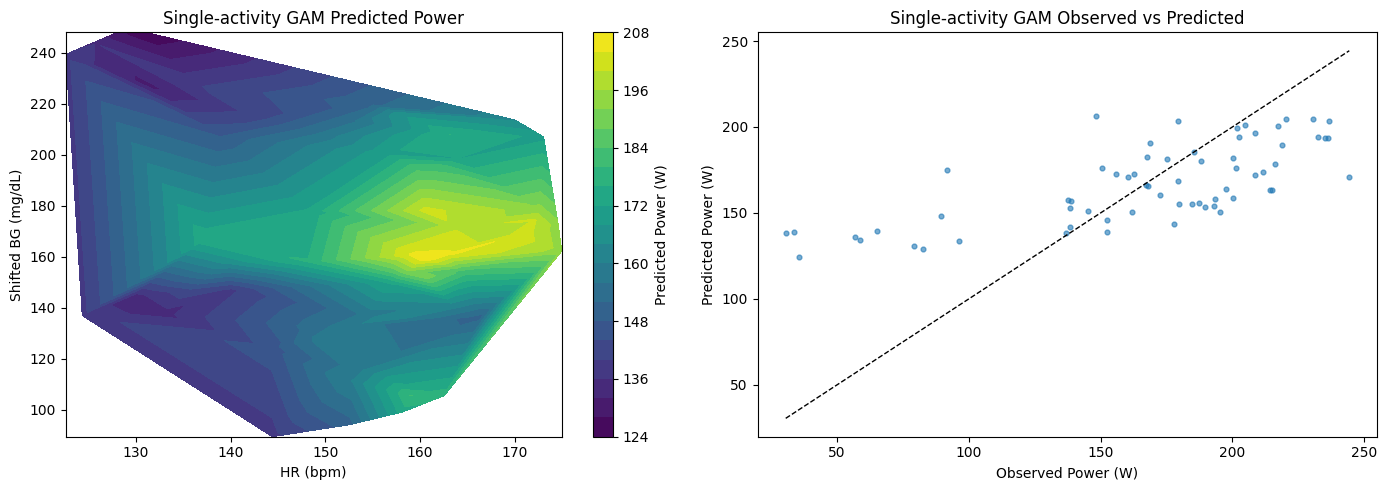

In [8]:
single_gam = run_single_activity_gam(result, bin_size=BIN_SIZE, min_samples=20)

if single_gam is None:
    print('Not enough power samples for single-activity GAM.')
else:
    print(f"GAM samples: {single_gam['samples']}")
    print(f"Best lag used for BG shift: {single_gam['best_lag']} min")
    print(f"In-sample R^2: {single_gam['r2']:.3f}")

    plot_gam_surface_and_fit(
        single_gam['gam_df'],
        single_gam['y_hat'],
        title_prefix='Single-activity GAM',
    )



## Pooled GAM Across Last 30 Activities

Fits one GAM using all recent activities (up to 30) that have enough aligned power data.

### Math & Reasoning
This cell fits a **pooled GAM** over recent eligible activities, increasing sample size and reducing session-specific variance. The model estimates a broader physiological response surface.

c:\Users\giaco\anaconda3\envs\jupyter-ai\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\giaco\anaconda3\envs\jupyter-ai\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\giaco\anaconda3\envs\jupyter-ai\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\Users\giaco\anaconda3\envs\jupyter-ai\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\giaco\anaconda3\envs\jupyter-ai\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\giaco\anaconda3\envs\jupyter-ai\Lib\site-packages\numpy\lib\_function_base

Eligible activities: 4
Pooled samples: 208
Pooled in-sample R^2: 0.736


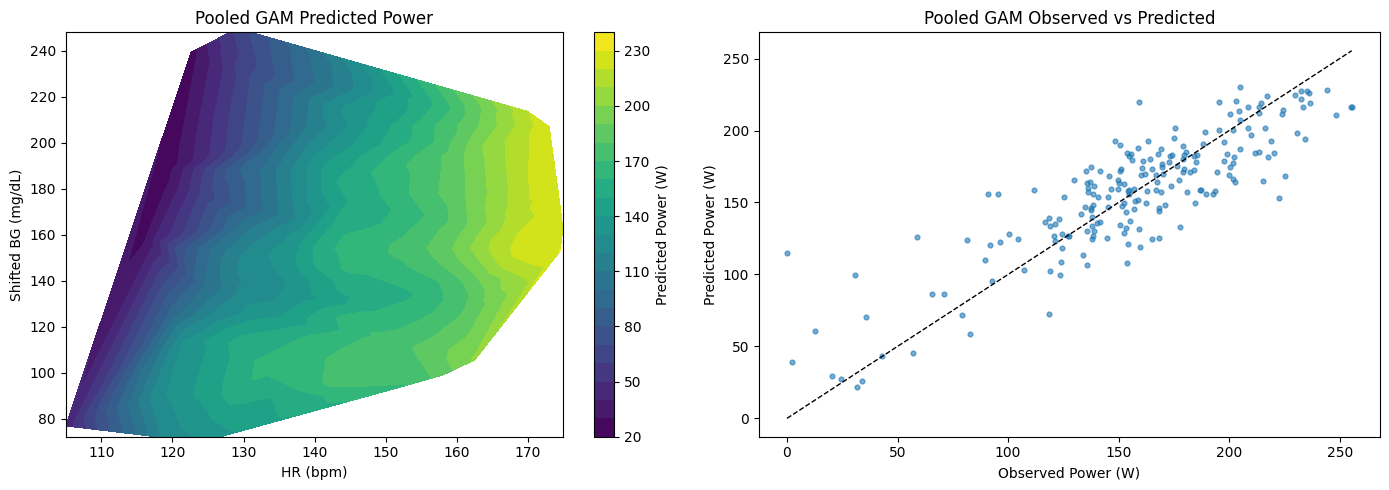

In [9]:
pooled_gam = run_pooled_gam(
    cfg=cfg,
    activities_df=activities_df,
    bin_size=BIN_SIZE,
    hi_quantile=HI_QUANTILE,
    max_activities=30,
    min_samples_per_activity=20,
)

if pooled_gam is None:
    print('No eligible activities found in last 30 for pooled GAM.')
else:
    pooled_gam_df = pooled_gam['pooled_gam_df']
    print(f"Eligible activities: {len(pooled_gam['used_activities'])}")
    print(f"Pooled samples: {pooled_gam['samples']}")
    print(f"Pooled in-sample R^2: {pooled_gam['r2']:.3f}")

    plot_gam_surface_and_fit(
        pooled_gam_df,
        pooled_gam['y_hat'],
        title_prefix='Pooled GAM',
    )
    pooled_gam_df.head()



## Most Efficient BG per 10 bpm

For each 10-bpm HR bin, compute the BG level linked to maximum power efficiency (`power/hr`) using lag-shifted BG.

### Math & Reasoning
This cell computes the BG value that maximizes efficiency (power/HR) within each 10-bpm bin on pooled data. It converts the fitted/shifted relationships into actionable HR-zone targets.

Pooled samples used: 208
Activities used: 4


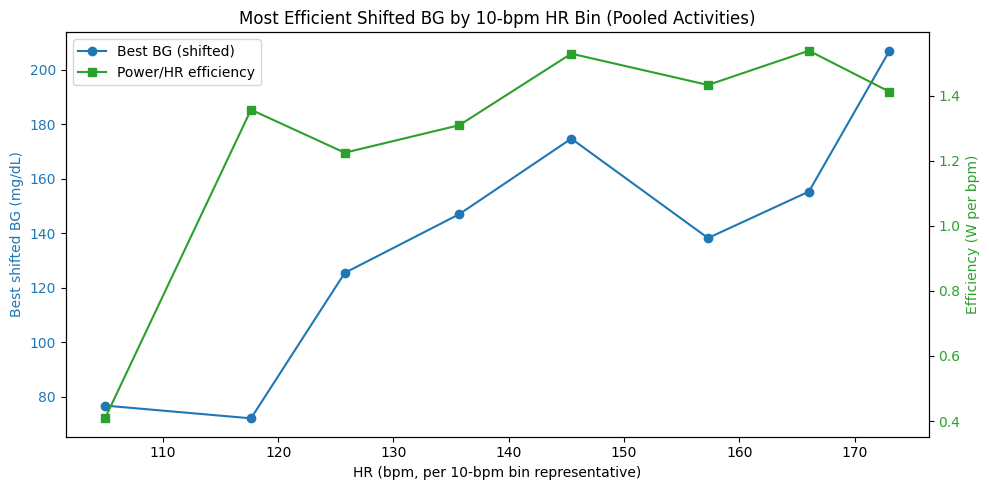

In [10]:
if 'pooled_gam_df' in globals() and isinstance(pooled_gam_df, pd.DataFrame) and not pooled_gam_df.empty:
    eff_pool_df = pooled_gam_df.copy()
else:
    pooled_for_eff = run_pooled_gam(
        cfg=cfg,
        activities_df=activities_df,
        bin_size=BIN_SIZE,
        hi_quantile=HI_QUANTILE,
        max_activities=30,
        min_samples_per_activity=20,
    )
    if pooled_for_eff is None:
        eff_pool_df = pd.DataFrame()
    else:
        eff_pool_df = pooled_for_eff['pooled_gam_df']

if eff_pool_df.empty:
    print('No eligible pooled activities available for efficiency analysis.')
else:
    best_bg_by_bin = compute_best_bg_by_hr_bin(eff_pool_df, hr_bin_size=10)
    print(f'Pooled samples used: {len(eff_pool_df)}')
    if 'activity_id' in eff_pool_df.columns:
        print(f"Activities used: {eff_pool_df['activity_id'].nunique()}")
    best_bg_by_bin

    plot_best_bg_by_hr_bin(best_bg_by_bin, title_suffix='Pooled Activities')



## Optional Save

### Math & Reasoning
This cell persists derived datasets to ensure reproducibility and enable external validation, sensitivity testing, or alternate modeling without re-querying APIs.

In [11]:
out_dir = 'output'
os.makedirs(out_dir, exist_ok=True)
safe_id = str(result['activity_id']).replace('/', '_')

result['aligned_raw_df'].to_csv(f'{out_dir}/aligned_hr_power_bg_raw_{safe_id}.csv', index=False)
result['aligned_df'].to_csv(f'{out_dir}/aligned_hr_power_bg_binned_5min_{safe_id}.csv', index=False)
result['lag_corr_df'].to_csv(f'{out_dir}/lag_corr_hr_bg_binned_5min_{safe_id}.csv', index=False)

print('Saved analysis CSVs for activity:', safe_id)

Saved analysis CSVs for activity: i133474657
